Importación de paquetes necesarios

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

Carga del dataset con los compuestos con actividad probada frente a FabI

In [2]:
ruta_input = "../data/raw/IC50_FabI.csv"
df_bruto = pd.read_csv(ruta_input, sep=';')
df_bruto.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL6034879,NaN,NaN,408.53,0.0,2.63,BDBM316893,O=C1CCc2cc(/C=C/C(=O)N3C[C@H]4CN(Cc5cccs5)C[C@...,IC50,'=',...,CHEMBL5726112,37,BindingDB Patent Bioactivity Data,NaN,2017,NaN,NaN,NaN,NaN,9130.00
1,CHEMBL568359,NaN,NaN,492.62,0.0,3.76,15e,CCCOc1c(CN(C)C(=O)/C=C/c2cnc3c(c2)CC2(CCN(C)CC...,IC50,'=',...,CHEMBL1155988,1,Scientific Literature,Bioorg Med Chem Lett,2009,NaN,NaN,NaN,NaN,26.00
2,CHEMBL3322674,NaN,NaN,349.39,0.0,2.27,AEA2,O=C1CCc2cc(/C=C/C(=O)N3CC(Oc4ccccc4)C3)cnc2N1,IC50,NaN,...,CHEMBL3352330,1,Scientific Literature,Eur J Med Chem,2014,NaN,NaN,NaN,NaN,NaN
3,CHEMBL294363,NaN,NaN,316.43,1.0,5.33,27,c1ccc(-c2ccc(Cn3cnc(-c4ccsc4)c3)cc2)cc1,IC50,'=',...,CHEMBL1133895,1,Scientific Literature,Bioorg Med Chem Lett,2001,NaN,NaN,NaN,NaN,7.66
4,CHEMBL421119,NaN,NaN,397.48,0.0,4.18,12,Nc1ccc(Cn2c3c(c4ccccc42)CCN(C(=O)c2ccc(O)cc2)C...,IC50,'=',...,CHEMBL1133924,1,Scientific Literature,Bioorg Med Chem Lett,2001,NaN,NaN,NaN,NaN,0.67


Verificación de que todas las filas examinan IC50 en S.aureus

In [3]:
organismos = df_bruto['Assay Organism'].unique()
print(f"Especies en el archivo original: {organismos}")
ensayos = df_bruto['Standard Type'].unique()
print(f"Tipos de ensayos: {ensayos}")

df_filtrado = df_bruto.dropna(subset=['Assay Organism'])
organismos = df_filtrado['Assay Organism'].unique()
print(f"Especies en el archivo filtrado: {organismos}")

Especies en el archivo original: ['Staphylococcus aureus' nan]
Tipos de ensayos: ['IC50']
Especies en el archivo filtrado: ['Staphylococcus aureus']


Filtrado del dataset para quedarnos únicamente con la información relevante de cara al entrenamiento del modelo (código smiles, standard relation y pChEMBL Value)

In [4]:
df_filtrado = df_filtrado[['Smiles','Standard Relation','pChEMBL Value']]
df_filtrado.head()

,Smiles,Standard Relation,pChEMBL Value
0,O=C1CCc2cc(/C=C/C(=O)N3C[C@H]4CN(Cc5cccs5)C[C@...,'=',5.04
1,CCCOc1c(CN(C)C(=O)/C=C/c2cnc3c(c2)CC2(CCN(C)CC...,'=',7.58
2,O=C1CCc2cc(/C=C/C(=O)N3CC(Oc4ccccc4)C3)cnc2N1,NaN,NaN
3,c1ccc(-c2ccc(Cn3cnc(-c4ccsc4)c3)cc2)cc1,'=',5.12
4,Nc1ccc(Cn2c3c(c4ccccc42)CCN(C(=O)c2ccc(O)cc2)C...,'=',6.17


Verificación de las dimensiones del df resultante e interpretación de las mismas

In [5]:
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 463 entries, 0 to 476
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Smiles             460 non-null    object 
 1   Standard Relation  417 non-null    object 
 2   pChEMBL Value      394 non-null    float64
dtypes: float64(1), object(2)
memory usage: 14.5+ KB


Podemos observar que el número de entradas pasó de 477 a 463 al eliminar las filas que no eran de S.auerus, además, no todas las variables de interés están resueltas para cada uno de los compuestos del dataframe. En este caso el cuello de botella lo marca el pChEMBL value, con 394 valores no nulos. 

Clearly we can't use all of these 463 entries for machine learning. We need a DataFrame which only contains rows where every column is non-null. To do this, we can use the Pandas function dropna with the 'how' argument set to 'any'. This means that rows which have missing values in any column are dropped. 

In [6]:
df_filtrado_dropna = df_filtrado.dropna(how='any')
print(df_filtrado_dropna.shape)

(391, 3)


After dropping null values, we are left with 391 rows.

Next, we only want to include the data for modelling if the Standard Relation is '='. We can check which Standard Relation symbols are in our DataFrame using unique to extract only the unique items in the column.

In [7]:
std_relations = df_filtrado_dropna['Standard Relation'].unique()
print(std_relations)

["'='"]


Looks like we don't need to do any cleaning there.

The final important thing we need to deal with is duplicate values. To find how many duplicates we have per compound, we can use the Pandas groupby function
to group the DataFrame in terms of the 'Smiles' column,size to count the number of entries, then finally sort_values in descending order.

In [8]:
df_filtrado_dropna.groupby(['Smiles']).size().sort_values(ascending=False)

Smiles
Oc1cc(Cl)ccc1Oc1ccc(Cl)cc1Cl                                 5
Cc1c(CN(C)C(=O)/C=C/c2cnc3c(c2)CCC(=O)N3)oc2ccccc12          4
CCc1cc(O)c(Oc2ccc(C(N)=O)cc2F)cc1F                           3
NC(=O)C1Cc2cc(/C=C/C(=O)N3CCC(COc4ccc(F)cc4)CC3)cnc2NC1=O    3
O=C1CCc2cc(/C=C/C(=O)N3CC(OCc4ccccc4)C3)cnc2N1               3
                                                            ..
O=c1cc(/C=C/c2ccoc2)occ1Oc1c(Cl)cccc1Cl                      1
O=c1cc(/C=C/c2ccoc2)occ1Oc1ccc(Cl)cc1Cl                      1
O=c1cc(/C=C/c2ccoc2)occ1Oc1cccc(Cl)c1Cl                      1
CC(=O)Nc1ccc(/C=C/C(=O)N2CC(c3oc4ccccc4c3C)C2)cn1            1
CC(=O)Nc1ccc(/C=C/C(=O)N(C)Cc2cc3ccccc3n2C)cn1               1
Length: 344, dtype: int64

Algunos compuestos están repetidos, uno incluso tiene 5 valores distintos. Notice that the length of the output is 344, meaning that there are 344 unique SMILES structures in the dataset. To deal with duplicates, we can again groupby SMILES, and this time take the mean of the
PChEMBL values from the grouped DataFrame.

In [9]:
df_filtrado_cleaned = df_filtrado_dropna.groupby(['Smiles','Standard Relation'])['pChEMBL Value'].mean()
df_filtrado_cleaned = pd.DataFrame(df_filtrado_cleaned)
df_filtrado_cleaned.head()

,,pChEMBL Value
Smiles,Standard Relation,
C#CN1C[C@@H]2CN(C(=O)/C=C/c3cnc4c(c3)CCC(=O)N4)C[C@@H]2C1,'=',5.10
C/C(Cc1ncccn1)=N\OC1CN(C(=O)/C=C/c2cnc3c(c2)CCC(=O)N3)C1,'=',6.06
C=C(C)COC1CN(C(=O)/C=C/c2cnc3c(c2)CCC(=O)N3)C1,'=',6.77
C=CC(C)(C)C12C=C(O)C(=O)N3/C(=C/c4cnc[nH]4)C(=O)NC31N(OC)c1ccccc12,'=',4.40
CC(=O)Nc1ccc(/C=C/C(=O)N(C)Cc2cc3ccccc3n2C)cn1,'=',6.52


Let's see what the distribution of pChEMBL values looks like. We can achieve this using the violinplot function in Seaborn. We just need to pass the DataFrame column to the function like so:

<Axes: xlabel='pChEMBL Value'>

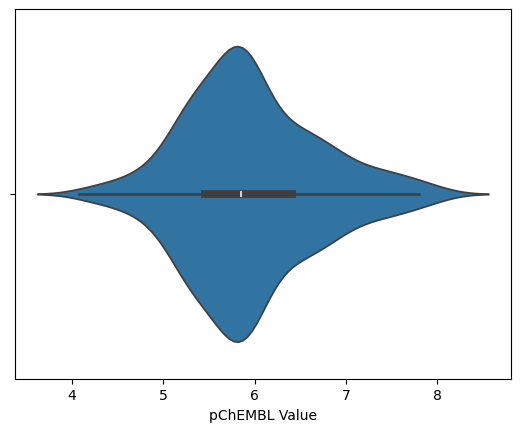

In [10]:
sns.violinplot(x=df_filtrado_cleaned['pChEMBL Value'])

In [11]:
df_filtrado_cleaned['pChEMBL Value'].describe()

count    344.000000
mean       5.952904
std        0.736894
min        4.080000
25%        5.460000
50%        5.855000
75%        6.405000
max        8.100000
Name: pChEMBL Value, dtype: float64